<a href="https://colab.research.google.com/github/Gene8848-gif/PBMC-Single-Cell-Immune-Cell-Profiling/blob/main/PBMC_Single_Cell_Immune_Cell_Profiling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Can we use single-cell gene-expression data to identify and characterize different immune-cell populations in peripheral blood?

In [8]:
!pip install scanpy

In [9]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [10]:
adata = sc.datasets.pbmc3k()

adata

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'
    layers: None (.X)

In [11]:
sc.pp.calculate_qc_metrics(
    adata,
    inplace=True
)

adata.obs[['n_genes_by_counts', 'total_counts']].head()

,n_genes_by_counts,total_counts
index,,
AAACATACAACCAC-1,781,2421.0
AAACATTGAGCTAC-1,1352,4903.0
AAACATTGATCAGC-1,1131,3149.0
AAACCGTGCTTCCG-1,960,2639.0
AAACCGTGTATGCG-1,522,981.0


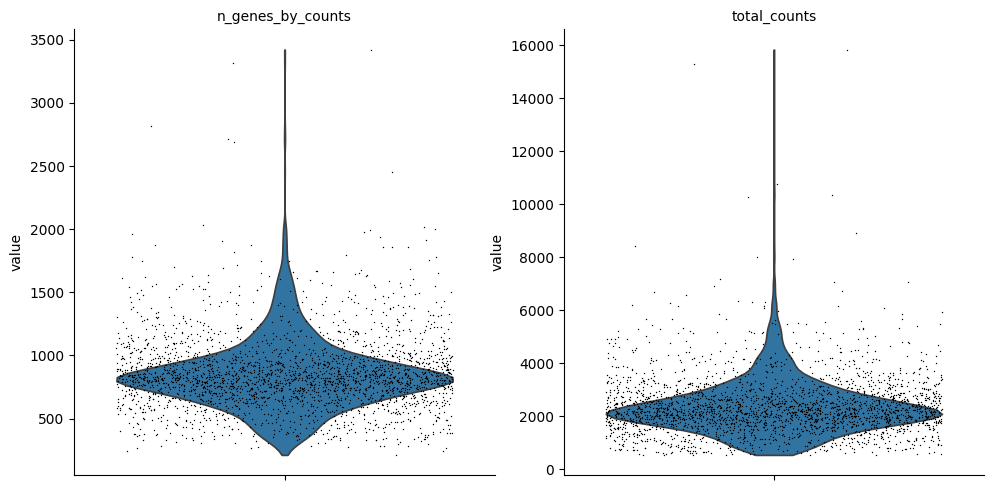

In [12]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts'],
    jitter=0.4,
    multi_panel=True
)

In [13]:
# Calculate percentage of mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

adata.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].head()

,n_genes_by_counts,total_counts,pct_counts_mt
index,,,
AAACATACAACCAC-1,781,2421.0,3.015283
AAACATTGAGCTAC-1,1352,4903.0,3.793596
AAACATTGATCAGC-1,1131,3149.0,0.889171
AAACCGTGCTTCCG-1,960,2639.0,1.743085
AAACCGTGTATGCG-1,522,981.0,1.223242


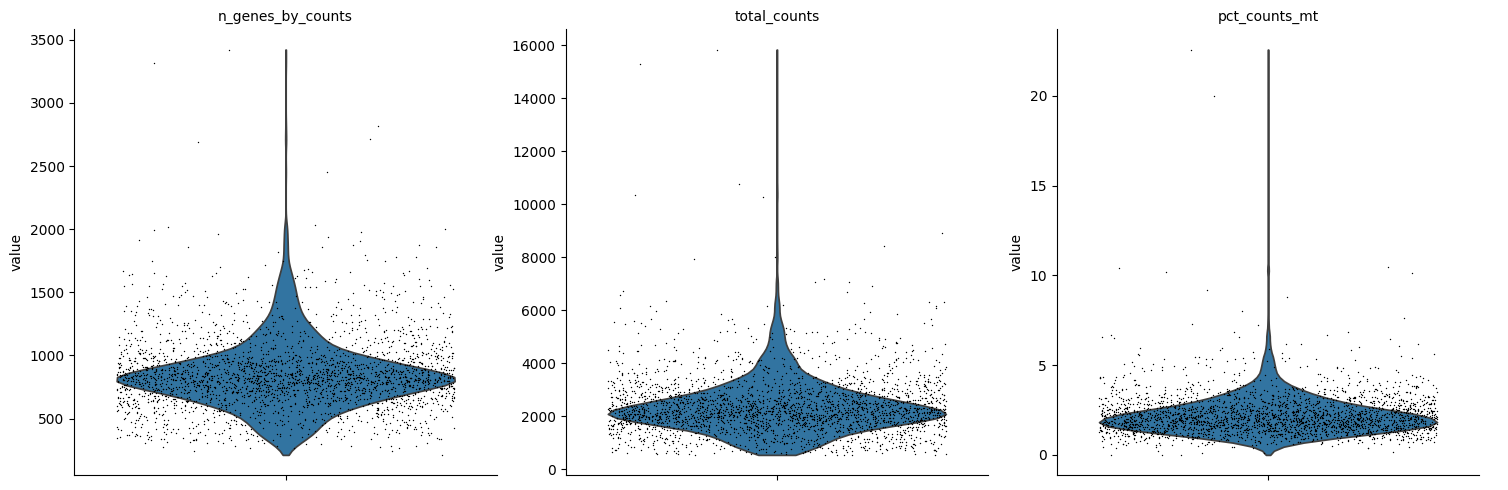

In [14]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

In [15]:
adata = adata[
    (adata.obs["n_genes_by_counts"] > 200) &
    (adata.obs["n_genes_by_counts"] < 2500) &
    (adata.obs["pct_counts_mt"] < 5)
].copy()

print("Cells after QC:", adata.n_obs)

Cells after QC: 2638


In [16]:
# Normalize each cell to the same total count
sc.pp.normalize_total(adata, target_sum=1e4)

# Log-transform the normalized expression values
sc.pp.log1p(adata)

# Preserve the normalized expression data for downstream marker analysis
adata.raw = adata

In [17]:
sc.pp.highly_variable_genes(
    adata,
    n_top_genes=2000,
    flavor="seurat"
)

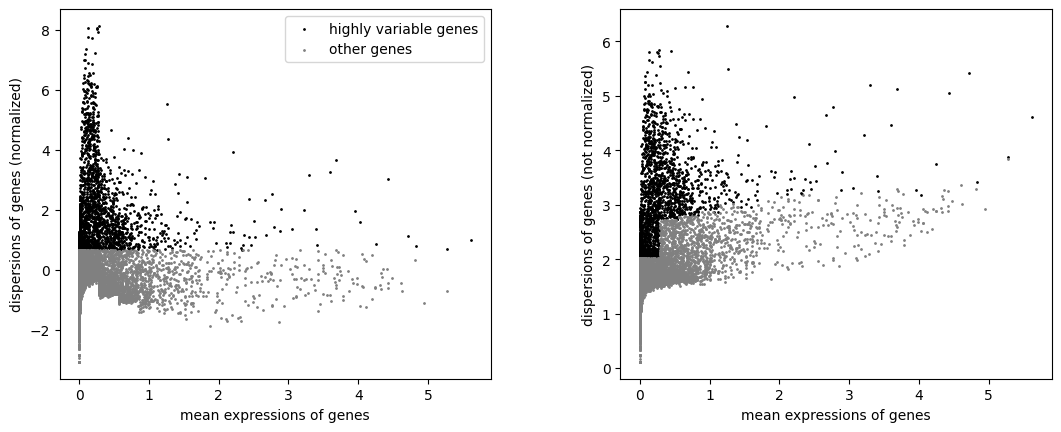

In [18]:
sc.pl.highly_variable_genes(adata)

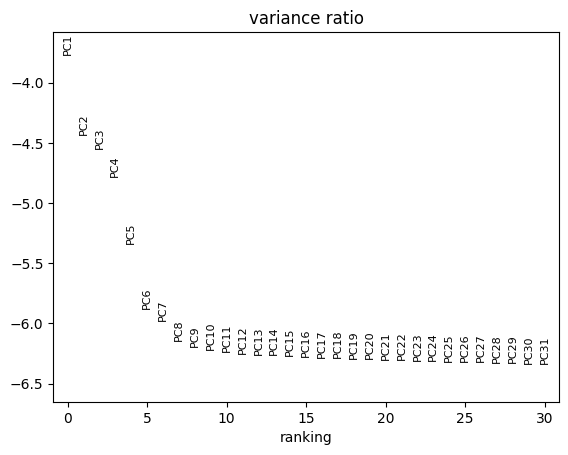

In [19]:
# Scale the highly variable genes
sc.pp.scale(adata, max_value=10)

# Perform PCA using the highly variable genes
sc.tl.pca(
    adata,
    mask_var="highly_variable",
    svd_solver="arpack"
)

# Visualize variance explained by each principal component
sc.pl.pca_variance_ratio(adata, log=True)

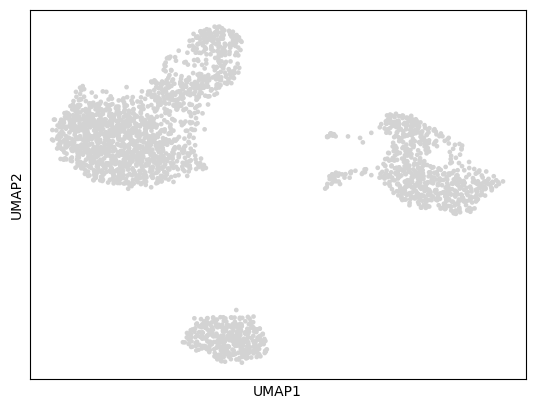

In [20]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=20)

sc.tl.umap(adata)

sc.pl.umap(adata)

In [21]:
!pip install leidenalg igraph

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 51.6 MB/s eta 0:00:00


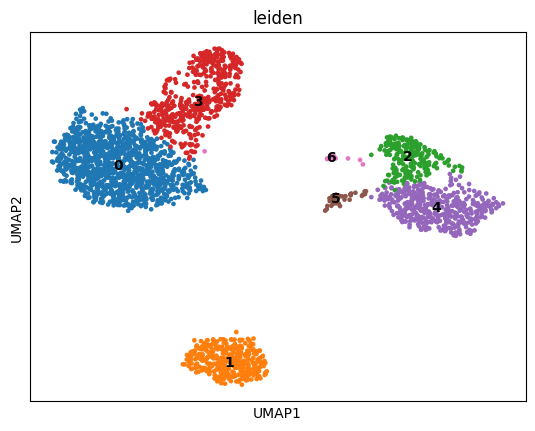

In [22]:
# Identify cell communities based on their neighborhood structure
sc.tl.leiden(
    adata,
    resolution=0.5,
    flavor="igraph",
    n_iterations=2,
    directed=False
)
# Visualize the resulting clusters
sc.pl.umap(
    adata,
    color="leiden",
    legend_loc="on data"
)

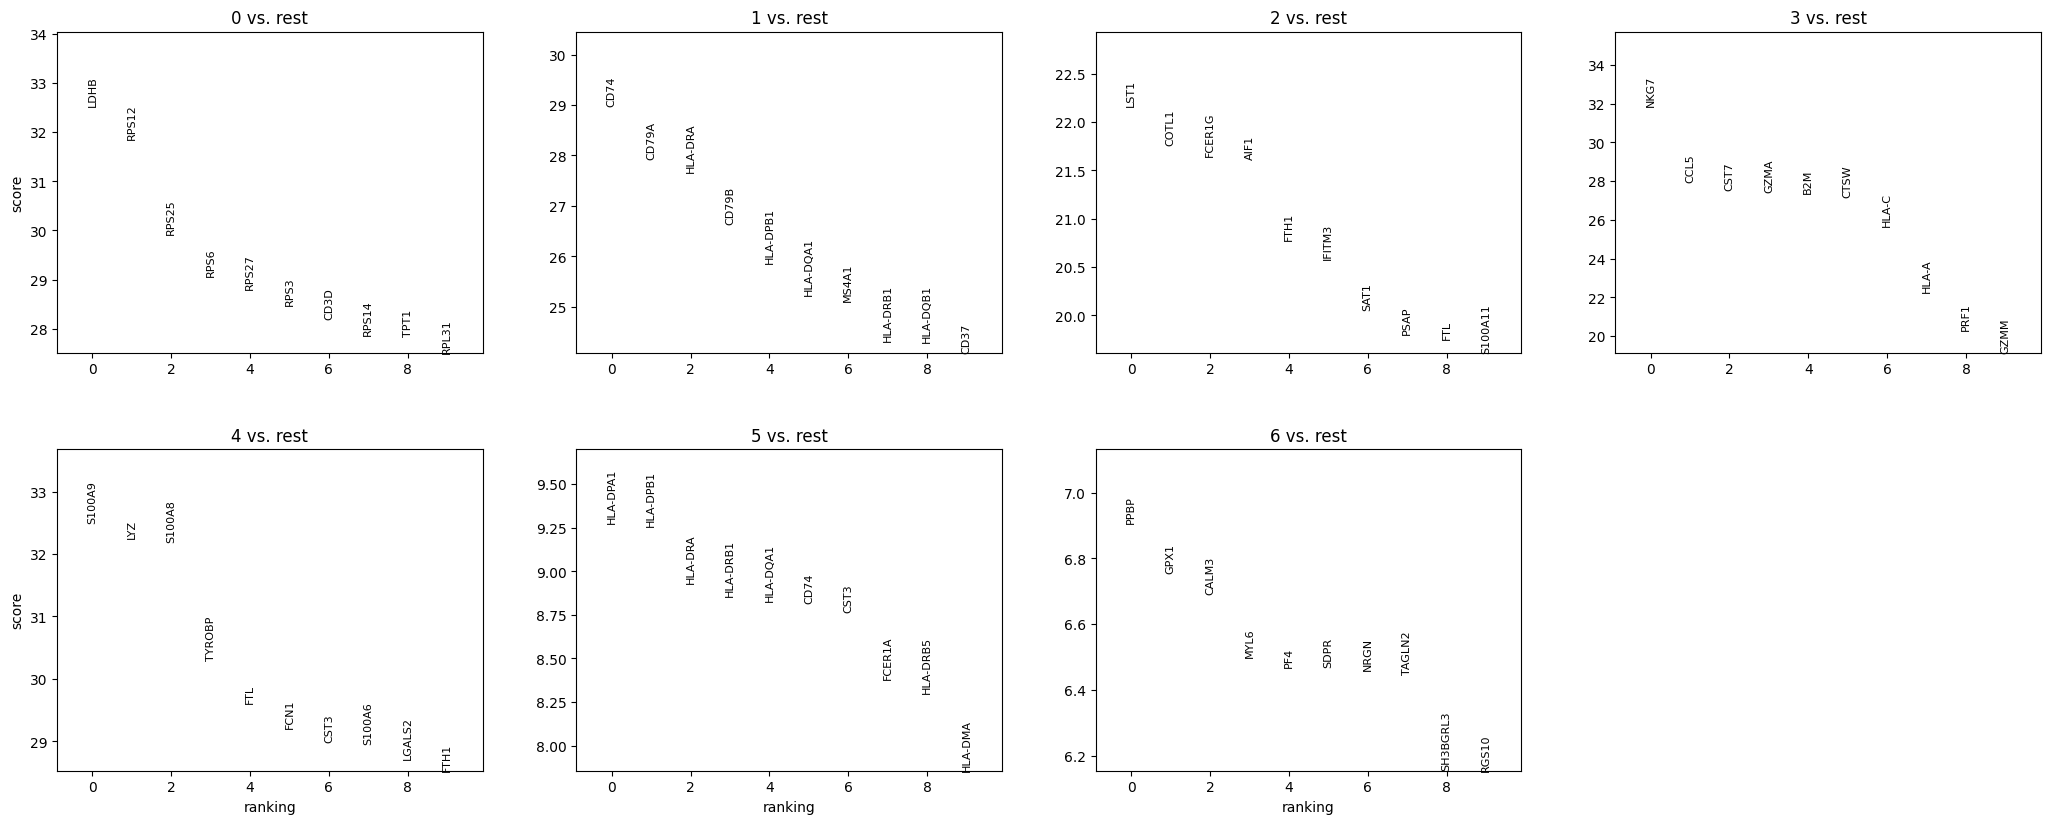

In [23]:
# Identify marker genes for each Leiden cluster
sc.tl.rank_genes_groups(
    adata,
    "leiden",
    method="wilcoxon"
)
# Extract marker genes into a dataframe
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)
top_markers = (
    markers
    .sort_values(["group", "pvals_adj"])
    .groupby("group")
    .head(10)
)

top_markers
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

In [24]:
# Show top marker genes for each cluster

markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

markers.head(20)

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LDHB,32.536201,2.750444,3.282099e-232,1.074494e-227
1,0,RPS12,31.861315,1.036523,9.176108e-223,1.502037e-218
2,0,RPS25,29.917917,1.154812,1.150772e-196,7.534798e-193
3,0,RPS6,29.077656,0.866425,6.881674e-186,3.218460e-182
4,0,RPS27,28.807047,1.001492,1.750509e-182,6.367574e-179
5,0,RPS3,28.469849,0.862724,2.768016e-178,9.061930e-175
6,0,CD3D,28.197668,3.226893,6.245625e-175,1.858812e-171
7,0,RPS14,27.867998,0.772986,6.519883e-171,1.778733e-167
8,0,TPT1,27.842888,0.960957,1.313379e-170,3.307492e-167
9,0,RPL31,27.509249,1.124889,1.360882e-166,2.784534e-163


In [25]:
top_markers = (
    markers
    .sort_values(["group", "pvals_adj"])
    .groupby("group")
    .head(10)
)

top_markers

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LDHB,32.536201,2.750444,3.282099e-232,1.074494e-227
1,0,RPS12,31.861315,1.036523,9.176108e-223,1.502037e-218
32737,0,CD74,-31.509888,-2.835845,6.359541e-218,6.939955e-214
32736,0,CYBA,-31.119944,-2.094899,1.294209e-212,1.059246e-208
2,0,RPS25,29.917917,1.154812,1.150772e-196,7.534798e-193
...,...,...,...,...,...,...
196433,6,SDPR,6.469792,11.347219,9.813811e-11,4.134391e-07
196434,6,NRGN,6.460244,8.737638,1.045342e-10,4.134391e-07
196435,6,TAGLN2,6.447569,4.399553,1.136585e-10,4.134391e-07
229165,6,RPL14,-6.476212,-4.193970,9.405412e-11,4.134391e-07


In [26]:
sc.tl.rank_genes_groups(
    adata,
    "leiden",
    method="wilcoxon"
)

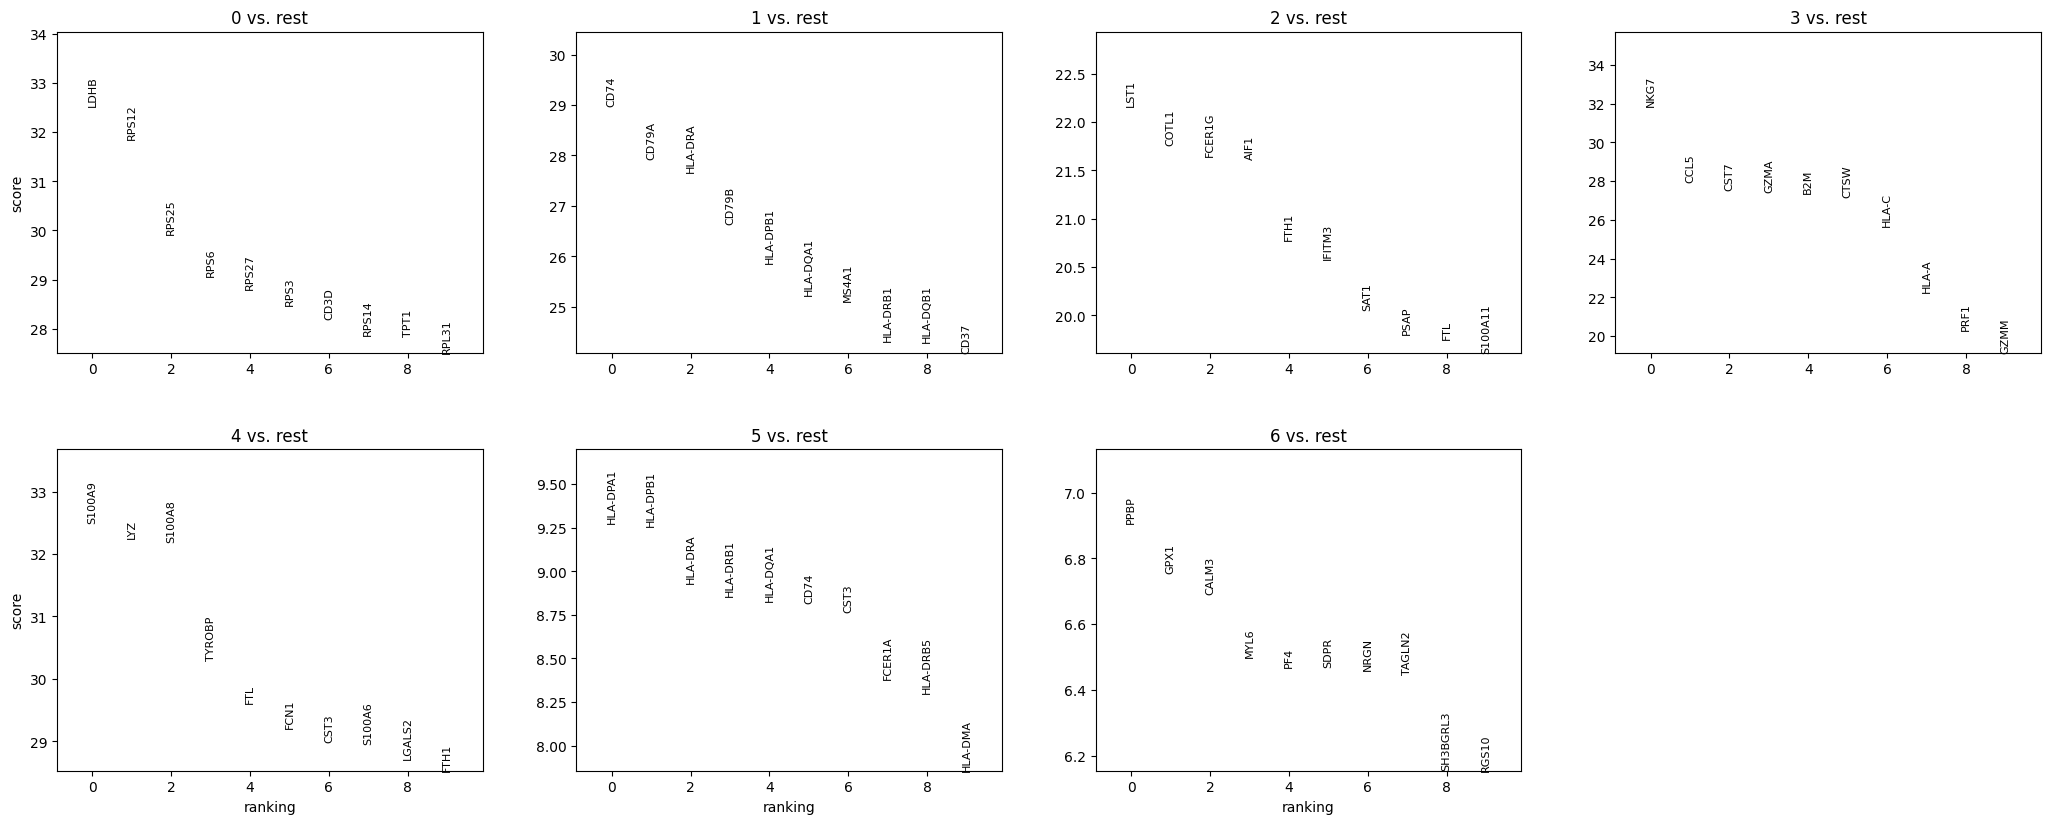

In [27]:
sc.pl.rank_genes_groups(
    adata,
    n_genes=10,
    sharey=False
)

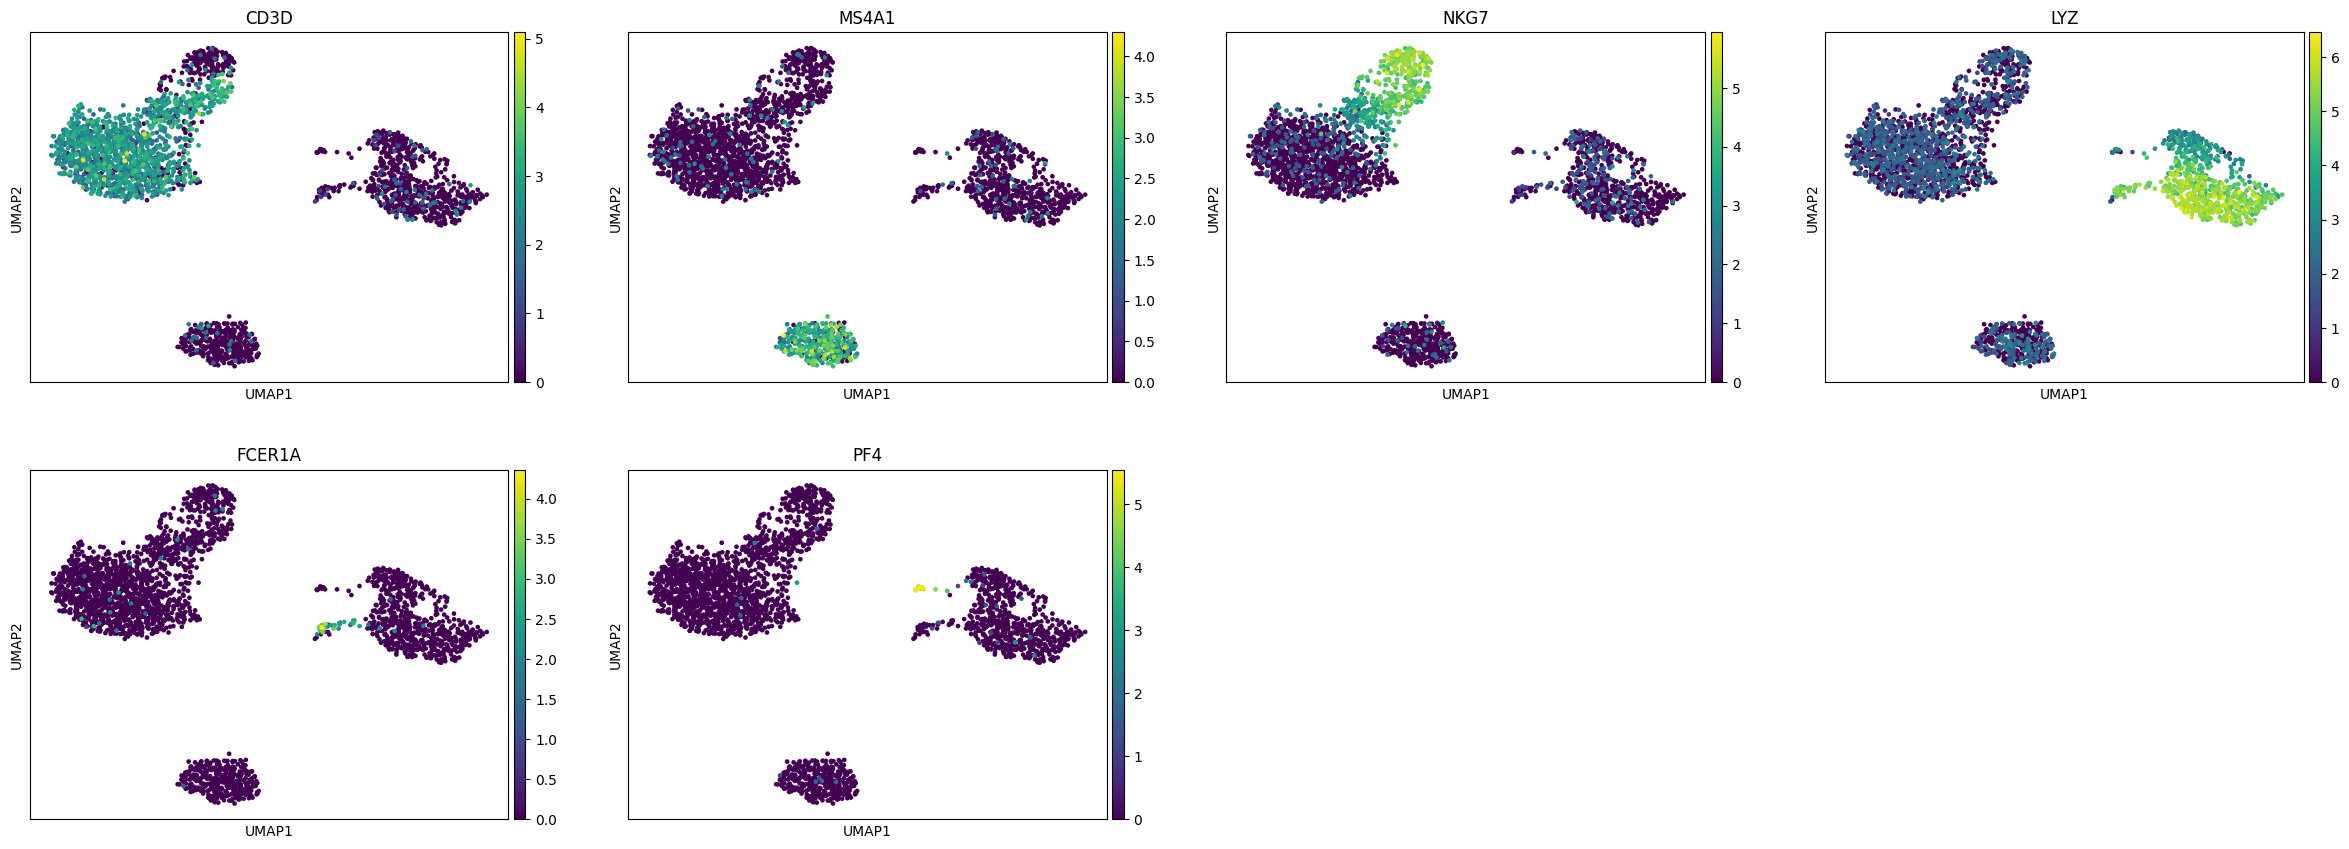

In [28]:
sc.pl.umap(
    adata,
    color=["CD3D", "MS4A1", "NKG7", "LYZ", "FCER1A", "PF4"]
)

In [29]:
marker_genes = {
    "T cells": ["CD3D", "CD3E", "TRBC1"],
    "NK cells": ["NKG7", "GNLY", "CCL5"],
    "B cells": ["MS4A1", "CD79A", "CD74"],
    "Monocytes": ["LYZ", "S100A8", "S100A9"],
    "Dendritic cells": ["FCER1A", "CST3", "HLA-DRA"],
    "Megakaryocytes": ["PF4", "PPBP", "RGS18"]
}

# Keep only genes that are actually present in the dataset
marker_genes_present = {
    cell_type: [gene for gene in genes if gene in adata.var_names]
    for cell_type, genes in marker_genes.items()
}

marker_genes_present

{'T cells': ['CD3D', 'CD3E'],
 'NK cells': ['NKG7', 'GNLY', 'CCL5'],
 'B cells': ['MS4A1', 'CD79A', 'CD74'],
 'Monocytes': ['LYZ', 'S100A8', 'S100A9'],
 'Dendritic cells': ['FCER1A', 'CST3', 'HLA-DRA'],
 'Megakaryocytes': ['PF4', 'PPBP', 'RGS18']}

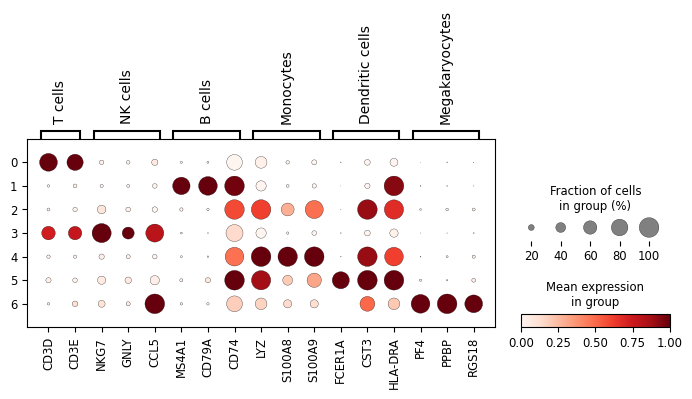

In [30]:
sc.pl.dotplot(
    adata,
    marker_genes_present,
    groupby="leiden",
    standard_scale="var"
)

In [31]:
markers = sc.get.rank_genes_groups_df(
    adata,
    group=None
)

markers.head()

,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,LDHB,32.536201,2.750444,3.282099e-232,1.074494e-227
1,0,RPS12,31.861315,1.036523,9.176108e-223,1.502037e-218
2,0,RPS25,29.917917,1.154812,1.150772e-196,7.534798e-193
3,0,RPS6,29.077656,0.866425,6.881674e-186,3.218460e-182
4,0,RPS27,28.807047,1.001492,1.750509e-182,6.367574e-179


In [32]:
cluster_4_markers = (
    markers[markers["group"] == "4"]
    .sort_values("pvals_adj")
    .head(20)
)

cluster_4_markers[["names", "scores", "logfoldchanges", "pvals_adj"]]

,names,scores,logfoldchanges,pvals_adj
130952,S100A9,32.490273,7.372525,4.789769e-227
130953,LYZ,32.258842,6.128341,4.328520e-224
130954,S100A8,32.195679,7.569715,2.213901e-223
130955,TYROBP,30.296169,5.352140,1.053842e-197
130956,FTL,29.617878,3.420439,5.759047e-189
130957,FCN1,29.214264,5.376498,6.972570e-184
130958,CST3,28.981972,5.477475,5.192763e-181
130959,S100A6,28.948450,2.956472,1.201179e-180
130960,LGALS2,28.707365,6.181038,1.123047e-177
163689,MALAT1,-28.544388,-1.583185,1.079589e-175


In [33]:
for cluster in ["2", "4"]:
    print(f"\nCluster {cluster}")
    display(
        markers[markers["group"] == cluster]
        .sort_values("pvals_adj")
        .head(15)[["names", "scores", "logfoldchanges", "pvals_adj"]]
    )


Cluster 2


,names,scores,logfoldchanges,pvals_adj
65476,LST1,22.167772,5.125140,2.301638e-104
65477,COTL1,21.758028,3.672393,9.492055e-101
65478,FCER1G,21.644463,4.767775,7.479223e-100
65479,AIF1,21.611677,4.866640,1.141626e-99
65480,FTH1,20.778624,2.936078,4.424147e-92
65481,IFITM3,20.579256,4.893732,2.297650e-90
65482,SAT1,20.054546,3.558698,8.615532e-86
65483,PSAP,19.806797,3.439036,1.064434e-83
65484,FTL,19.749001,3.183708,2.976255e-83
65485,S100A11,19.610956,3.391719,4.081390e-82



Cluster 4


,names,scores,logfoldchanges,pvals_adj
130952,S100A9,32.490273,7.372525,4.789769e-227
130953,LYZ,32.258842,6.128341,4.328520e-224
130954,S100A8,32.195679,7.569715,2.213901e-223
130955,TYROBP,30.296169,5.352140,1.053842e-197
130956,FTL,29.617878,3.420439,5.759047e-189
130957,FCN1,29.214264,5.376498,6.972570e-184
130958,CST3,28.981972,5.477475,5.192763e-181
130959,S100A6,28.948450,2.956472,1.201179e-180
130960,LGALS2,28.707365,6.181038,1.123047e-177
163689,MALAT1,-28.544388,-1.583185,1.079589e-175


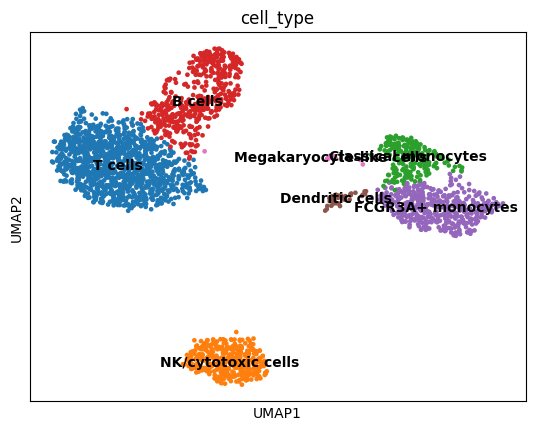

In [34]:
# Assign biological cell-type labels to each Leiden cluster
adata.obs["cell_type"] = adata.obs["leiden"].map({
    "0": "T cells",
    "1": "NK/cytotoxic cells",
    "2": "Classical monocytes",
    "3": "B cells",
    "4": "FCGR3A+ monocytes",
    "5": "Dendritic cells",
    "6": "Megakaryocyte-like cells"
})

# Visualize the annotated cell populations
sc.pl.umap(
    adata,
    color="cell_type",
    legend_loc="on data"
)

In [35]:
adata.obs["cell_type"].value_counts()

cell_type
T cells                     1148
B cells                      456
FCGR3A+ monocytes            438
NK/cytotoxic cells           345
Classical monocytes          200
Dendritic cells               35
Megakaryocyte-like cells      16
Name: count, dtype: int64

In [36]:
cell_counts = adata.obs["cell_type"].value_counts()

cell_percentages = (
    cell_counts / cell_counts.sum() * 100
).round(2)

cell_percentages

cell_type
T cells                     43.52
B cells                     17.29
FCGR3A+ monocytes           16.60
NK/cytotoxic cells          13.08
Classical monocytes          7.58
Dendritic cells              1.33
Megakaryocyte-like cells     0.61
Name: count, dtype: float64

## Biological Interpretation

Single-cell RNA-seq analysis identified seven major cell populations within the PBMC dataset based on cluster-specific gene-expression patterns.

The major populations identified were:

- **T cells** – supported by markers such as CD3D and CD3E.
- **NK/cytotoxic cells** – characterized by NKG7, GNLY, and CCL5.
- **Classical monocytes** – characterized by S100A8, S100A9, LYZ, and FCN1.
- **B cells** – supported by MS4A1, CD79A, and CD74.
- **FCGR3A+ monocytes** – characterized by FCGR3A, LST1, FCER1G, AIF1, and CST3.
- **Dendritic cells** – supported by FCER1A, HLA-DRA, and CST3.
- **Megakaryocyte-like cells** – characterized by PF4, PPBP, and RGS18.

T cells represented the largest population, followed by NK/cytotoxic cells, classical monocytes, B cells, and FCGR3A+ monocytes. Dendritic cells and megakaryocyte-like cells represented smaller populations.

The distinction between classical and FCGR3A+ monocytes demonstrates heterogeneity within the myeloid compartment. These cell identities were assigned based on patterns of marker-gene expression rather than individual genes alone.

### Limitations

Cell-type annotations in this analysis are working annotations based on marker-gene expression. More detailed annotation methods and additional biological validation would be required to establish definitive cell identities.

## Conclusion

This analysis demonstrates a complete single-cell RNA-seq workflow for identifying immune-cell populations in peripheral blood. Using the PBMC3k dataset, quality control, normalization, highly variable gene selection, PCA, UMAP, Leiden clustering, and marker-gene analysis were used to identify seven major cell populations.

The analysis highlights the heterogeneity of PBMCs and demonstrates how gene-expression patterns can be used to distinguish lymphoid and myeloid populations, including different monocyte subtypes.

This project provided practical experience with single-cell RNA-seq data analysis using Python and Scanpy and established a foundation for applying similar computational approaches to more complex disease and tumor-immune datasets.